In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/cleaned_transactions.csv")

# Display first 5 rows
df.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,...,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,month,year,amount_dest
0,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,0,...,0.223,0,0,0.0,0,18,Monday,10,2022,375.93
1,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,1,...,0.268,0,1,0.0,0,20,Monday,10,2022,2660.30
2,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,0,...,0.176,0,0,0.0,0,23,Monday,10,2022,1145.21
3,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,0,...,0.391,0,0,0.0,0,1,Tuesday,10,2022,55.01
4,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,0,...,0.257,0,0,0.0,0,9,Tuesday,10,2022,16746.67


In [3]:
# Check dataset shape and structure

print("Dataset shape:", df.shape)

df.info()

Dataset shape: (10940, 27)
<class 'pandas.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  10940 non-null  str    
 1   home_country               10940 non-null  str    
 2   source_currency            10940 non-null  str    
 3   dest_currency              10940 non-null  str    
 4   channel                    10940 non-null  str    
 5   amount_src                 10940 non-null  float64
 6   amount_usd                 10940 non-null  float64
 7   fee                        10940 non-null  float64
 8   exchange_rate_src_to_dest  10940 non-null  float64
 9   new_device                 10940 non-null  int64  
 10  ip_country                 10940 non-null  str    
 11  location_mismatch          10940 non-null  int64  
 12  ip_risk_score              10940 non-null  float64
 13  kyc_tier                   109

In [4]:
# Check fraud distribution

print(df["is_fraud"].value_counts())

fraud_rate = df["is_fraud"].mean() * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

is_fraud
0    9951
1     989
Name: count, dtype: int64
Fraud Rate: 9.04%


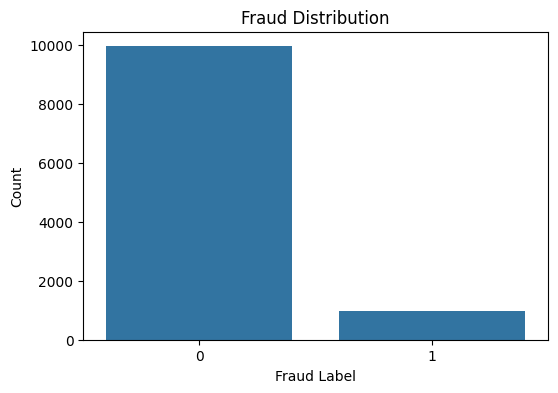

In [5]:
# Visualize fraud distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    x="is_fraud",
    data=df
)

plt.title("Fraud Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Count")

plt.show()

In [6]:
# Fraud rate by transaction channel

channel_fraud = (
    df.groupby("channel")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

print(channel_fraud)

channel
web        0.165807
atm        0.082822
mobile     0.047436
unknown    0.027027
Name: is_fraud, dtype: float64


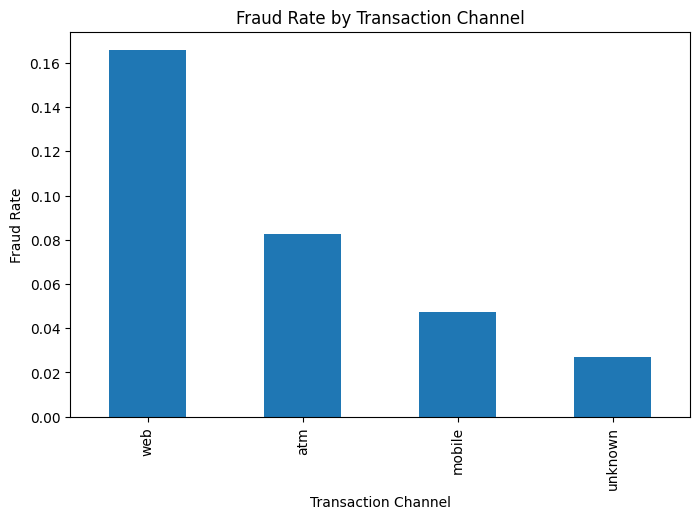

In [7]:
# Visualize fraud rate by transaction channel

plt.figure(figsize=(8, 5))

channel_fraud.plot(kind="bar")

plt.title("Fraud Rate by Transaction Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Fraud Rate")

plt.show()

In [8]:
# KYC tier fraud analysis

kyc_analysis = pd.crosstab(
    df["kyc_tier"],
    df["is_fraud"],
    normalize="index"
) * 100

print(kyc_analysis.round(2))

is_fraud      0      1
kyc_tier              
enhanced  97.72   2.28
low       48.26  51.74
standard  94.80   5.20
unknown   97.48   2.52


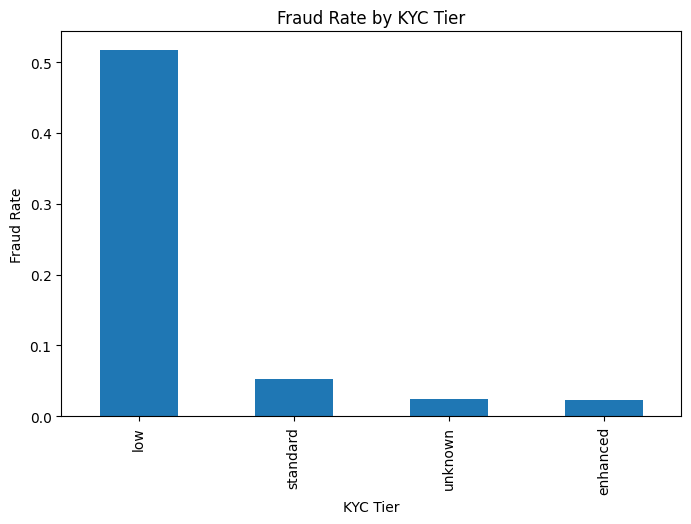

In [9]:
# Fraud rate by KYC tier

kyc_fraud = (
    df.groupby("kyc_tier")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

kyc_fraud.plot(kind="bar")

plt.title("Fraud Rate by KYC Tier")
plt.xlabel("KYC Tier")
plt.ylabel("Fraud Rate")

plt.show()

In [10]:
# Average transaction velocity by fraud label

velocity_analysis = df.groupby("is_fraud")[
    ["txn_velocity_1h", "txn_velocity_24h"]
].mean()

print(velocity_analysis)

          txn_velocity_1h  txn_velocity_24h
is_fraud                                   
0                0.155361          0.271229
1                3.872599          5.510617


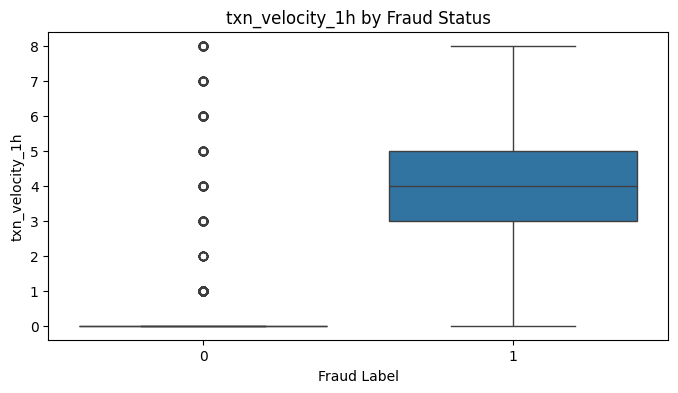

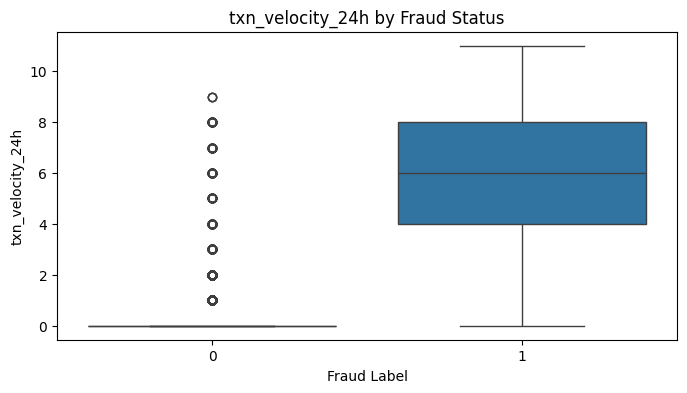

In [11]:
# Boxplot of transaction velocity by fraud status

velocity_features = [
    "txn_velocity_1h",
    "txn_velocity_24h"
]

for col in velocity_features:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x="is_fraud",
        y=col,
        data=df
    )
    
    plt.title(f"{col} by Fraud Status")
    plt.xlabel("Fraud Label")
    plt.ylabel(col)
    
    plt.show()

In [12]:
# Device trust score comparison

device_trust = df.groupby("is_fraud")["device_trust_score"].mean()

print(device_trust)

is_fraud
0    0.701910
1    0.314668
Name: device_trust_score, dtype: float64


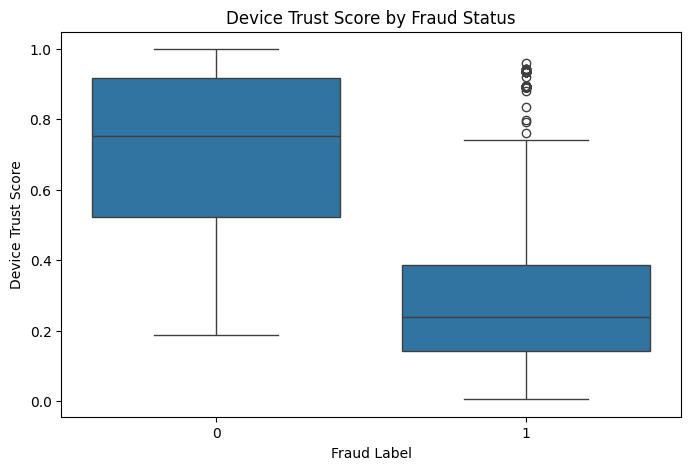

In [13]:
# Visualize device trust score by fraud status

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="is_fraud",
    y="device_trust_score",
    data=df
)

plt.title("Device Trust Score by Fraud Status")
plt.xlabel("Fraud Label")
plt.ylabel("Device Trust Score")

plt.show()

In [14]:
# IP risk score comparison

ip_risk = df.groupby("is_fraud")["ip_risk_score"].mean()

print(ip_risk)

is_fraud
0    0.336642
1    0.850908
Name: ip_risk_score, dtype: float64


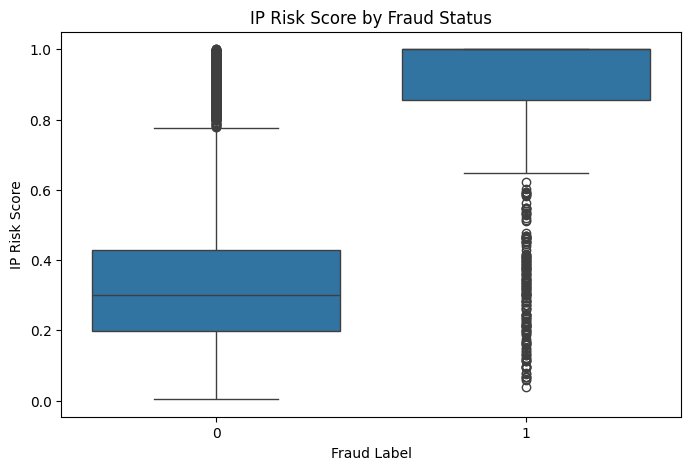

In [15]:
# Visualize IP risk score by fraud status

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="is_fraud",
    y="ip_risk_score",
    data=df
)

plt.title("IP Risk Score by Fraud Status")
plt.xlabel("Fraud Label")
plt.ylabel("IP Risk Score")

plt.show()

In [16]:
# New device fraud analysis

new_device_analysis = pd.crosstab(
    df["new_device"],
    df["is_fraud"],
    normalize="index"
) * 100

print(new_device_analysis.round(2))

is_fraud        0      1
new_device              
0           95.03   4.97
1           61.04  38.96


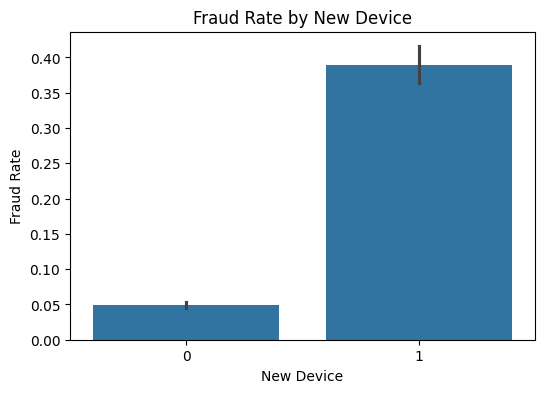

In [17]:
# Visualize fraud rate by new device

plt.figure(figsize=(6, 4))

sns.barplot(
    x="new_device",
    y="is_fraud",
    data=df
)

plt.title("Fraud Rate by New Device")
plt.xlabel("New Device")
plt.ylabel("Fraud Rate")

plt.show()

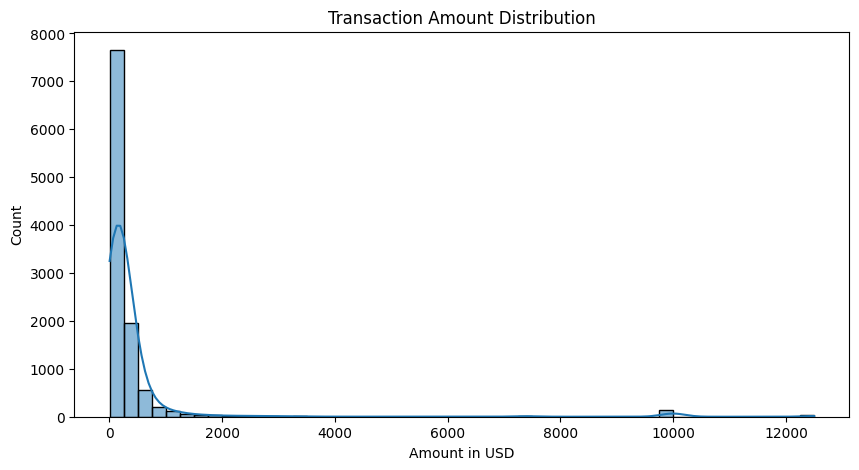

In [18]:
# Transaction amount distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["amount_usd"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount in USD")

plt.show()

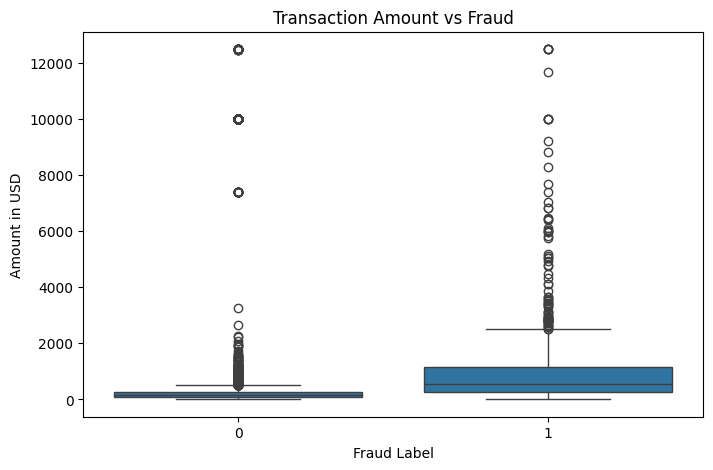

In [19]:
# Transaction amount vs fraud

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="is_fraud",
    y="amount_usd",
    data=df
)

plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud Label")
plt.ylabel("Amount in USD")

plt.show()

In [20]:
# Check implied USD conversion rate by source currency

usd_conversion_rate = (
    df.groupby("source_currency")
    .apply(lambda x: (x["amount_usd"] / x["amount_src"]).mean())
)

print(usd_conversion_rate)

source_currency
cad    0.747826
gbp    1.253077
usd    1.014185
dtype: float64


In [21]:
# IP country distribution

print(df["ip_country"].value_counts())

ip_country
us         6610
uk         2333
ca         1677
unknown     320
Name: count, dtype: int64


In [22]:
# Fraud rate by IP country

country_fraud = (
    df.groupby("ip_country")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

print(country_fraud)

ip_country
ca         0.180680
uk         0.151736
us         0.049168
unknown    0.021875
Name: is_fraud, dtype: float64


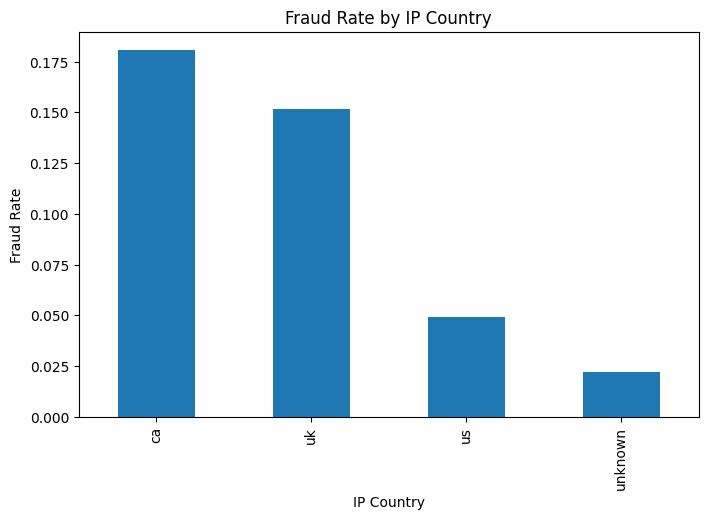

In [23]:
# Visualize fraud rate by IP country

plt.figure(figsize=(8, 5))

country_fraud.plot(kind="bar")

plt.title("Fraud Rate by IP Country")
plt.xlabel("IP Country")
plt.ylabel("Fraud Rate")

plt.show()

In [24]:
# Source currency distribution for unknown IP country

unknown_ip_currency = (
    df[df["ip_country"] == "unknown"]["source_currency"]
    .value_counts()
)

print(unknown_ip_currency)

source_currency
usd    224
gbp     72
cad     24
Name: count, dtype: int64


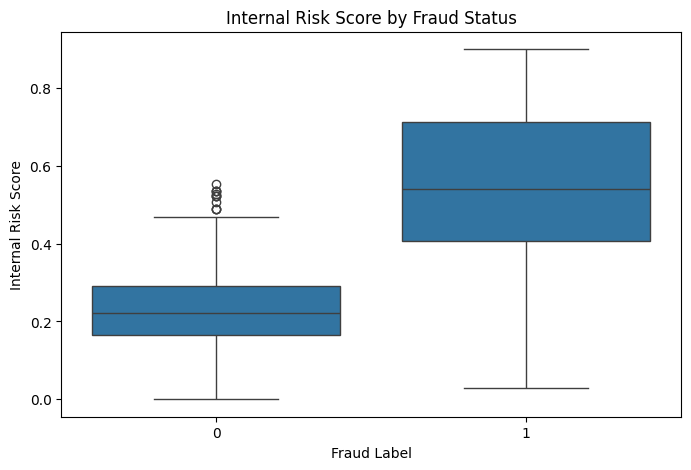

In [25]:
# Internal risk score by fraud status

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="is_fraud",
    y="risk_score_internal",
    data=df
)

plt.title("Internal Risk Score by Fraud Status")
plt.xlabel("Fraud Label")
plt.ylabel("Internal Risk Score")

plt.show()

In [26]:
# Select numerical columns for correlation analysis

numeric_df = df.select_dtypes(
    include=["int64", "float64", "int32"]
)

# Calculate correlation matrix

correlation_matrix = numeric_df.corr()

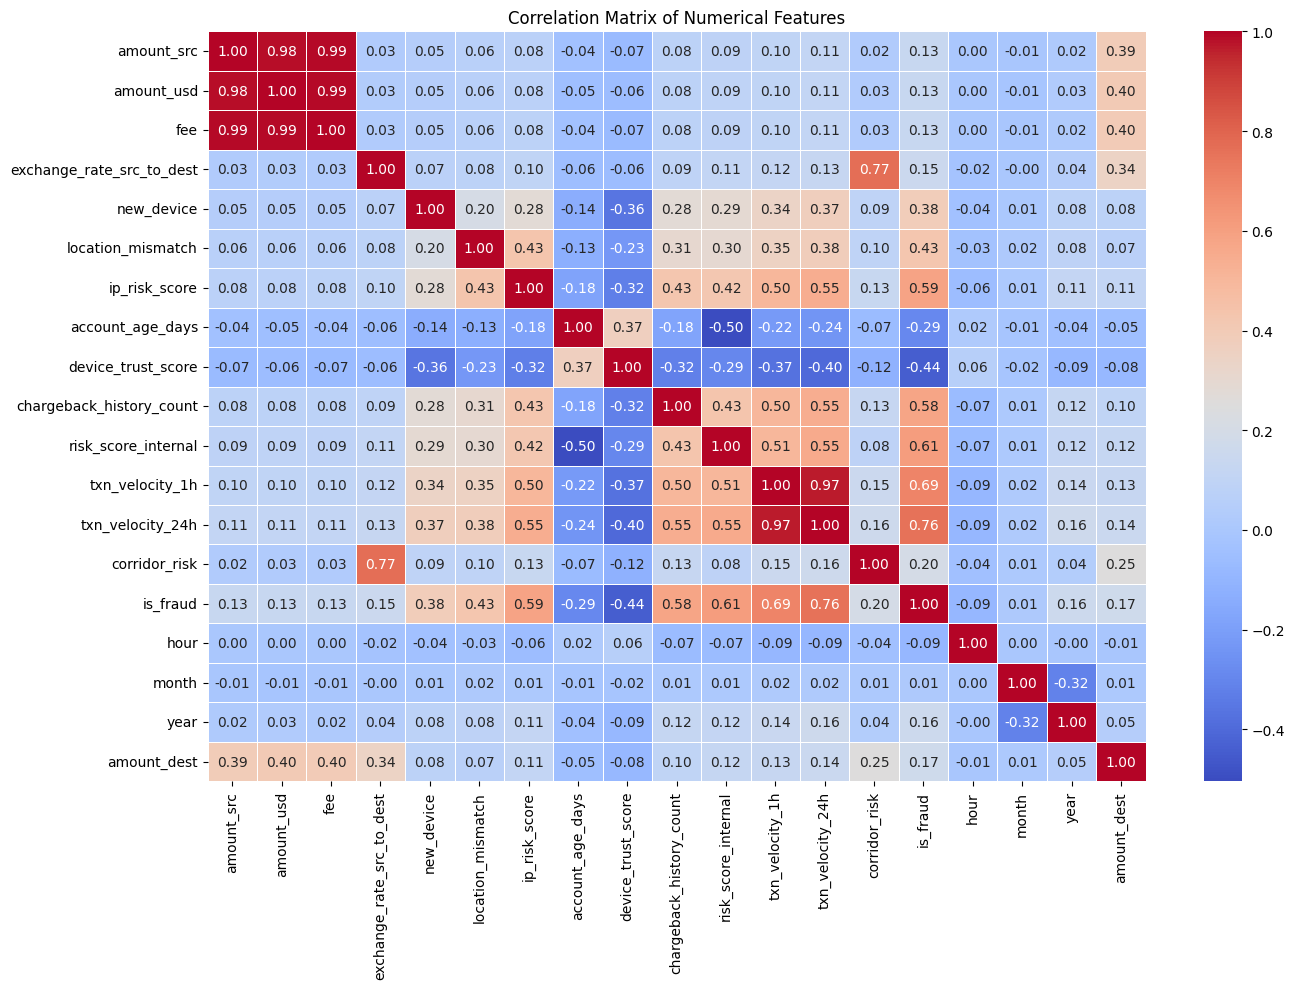

In [27]:
# Correlation heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

In [28]:
# Correlation of numerical features with fraud target

corr_target = (
    correlation_matrix["is_fraud"]
    .sort_values(ascending=False)
)

print(corr_target)

is_fraud                     1.000000
txn_velocity_24h             0.755571
txn_velocity_1h              0.694519
risk_score_internal          0.607491
ip_risk_score                0.586965
chargeback_history_count     0.582796
location_mismatch            0.425649
new_device                   0.384675
corridor_risk                0.197161
amount_dest                  0.169380
year                         0.156941
exchange_rate_src_to_dest    0.153780
amount_usd                   0.133938
fee                          0.133083
amount_src                   0.131581
month                        0.014332
hour                        -0.087813
account_age_days            -0.288835
device_trust_score          -0.440542
Name: is_fraud, dtype: float64


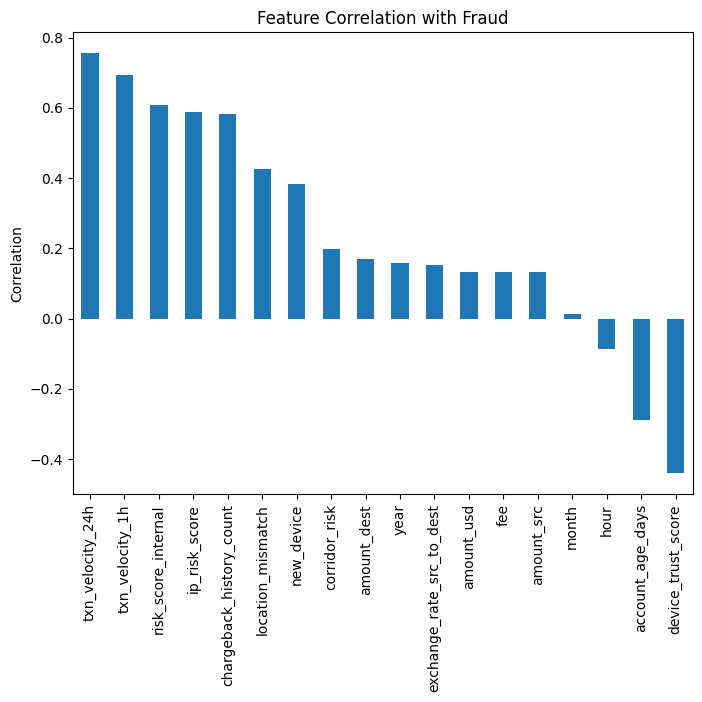

In [29]:
# Visualize feature correlation with fraud

plt.figure(figsize=(8, 6))

corr_target.drop("is_fraud").plot(
    kind="bar"
)

plt.title("Feature Correlation with Fraud")
plt.ylabel("Correlation")

plt.show()

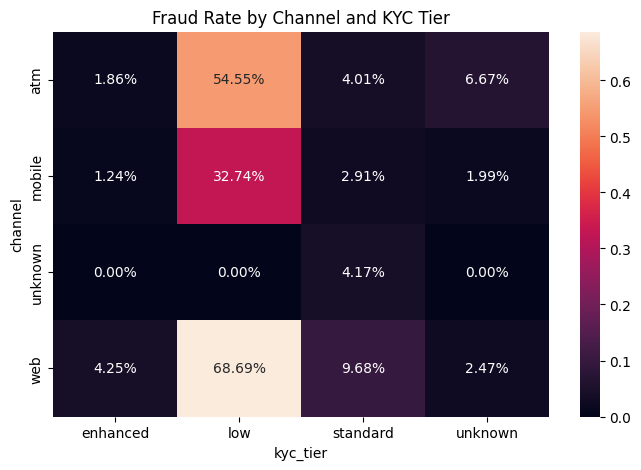

In [30]:
# Fraud rate by channel and KYC tier

fraud_heatmap = pd.pivot_table(
    df,
    values="is_fraud",
    index="channel",
    columns="kyc_tier",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    fraud_heatmap,
    annot=True,
    fmt=".2%"
)

plt.title("Fraud Rate by Channel and KYC Tier")

plt.show()

In [31]:
# Final EDA summary values

print("Fraud Rate:", round(df["is_fraud"].mean() * 100, 2), "%")

print("\nChannel Counts:")
print(df["channel"].value_counts())

print("\nKYC Tier Counts:")
print(df["kyc_tier"].value_counts())

print("\nIP Country Counts:")
print(df["ip_country"].value_counts())

Fraud Rate: 9.04 %

Channel Counts:
channel
mobile     6240
web        3685
atm         978
unknown      37
Name: count, dtype: int64

KYC Tier Counts:
kyc_tier
standard    7786
enhanced    1802
low         1034
unknown      318
Name: count, dtype: int64

IP Country Counts:
ip_country
us         6610
uk         2333
ca         1677
unknown     320
Name: count, dtype: int64


## Key EDA Findings

- Fraud represents approximately 9.04% of the cleaned dataset.
- Web transactions show the highest fraud rate among transaction channels.
- Low KYC tier customers have a significantly higher fraud rate.
- Fraudulent transactions show much higher transaction velocity in both 1-hour and 24-hour windows.
- Fraudulent transactions have lower average device trust scores.
- Fraudulent transactions have higher average IP risk scores.
- New devices are associated with higher fraud risk.
- Behavioural and risk-based features appear more predictive than transaction amount alone.